0. Импорты и настройки

In [1]:
# Базовые библиотеки
import os
import json
import math
import time
import random
from typing import Dict, List, Tuple, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, Dataset

# Torchvision
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

# Seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Пути
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
Device: cuda


Часть A: Классификация на CIFAR100

In [2]:
# CIFAR100 mean/std (стандартные значения)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

# Базовый transform без аугментаций
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Transform с аугментациями
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Transform для ResNet (ImageNet stats + resize)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

resnet_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_transform_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_cifar100(root: str = "./data", train_transform=None, eval_transform=None):
    """Загрузка CIFAR100 с разными transforms для train/eval"""
    if train_transform is None:
        train_transform = base_transform
    if eval_transform is None:
        eval_transform = base_transform
    
    ds_train_full = torchvision.datasets.CIFAR100(
        root=root, train=True, download=True, transform=train_transform
    )
    ds_test = torchvision.datasets.CIFAR100(
        root=root, train=False, download=True, transform=eval_transform
    )
    return ds_train_full, ds_test

# Загружаем базовый датасет для sanity-check
ds_train_full, ds_test = load_cifar100()
class_names = ds_train_full.classes
print(f"Train: {len(ds_train_full)}, Test: {len(ds_test)}")
print(f"Classes: {len(class_names)}")

100%|███████████████████████████████████████████████████████████████████████████████| 169M/169M [00:10<00:00, 16.5MB/s]


Extracting ./data\cifar-100-python.tar.gz to ./data
Files already downloaded and verified
Train: 50000, Test: 10000
Classes: 100


Sanity-check данных

x.shape: torch.Size([16, 3, 32, 32]), y.shape: torch.Size([16])
x.dtype: torch.float32, y.dtype: torch.int64


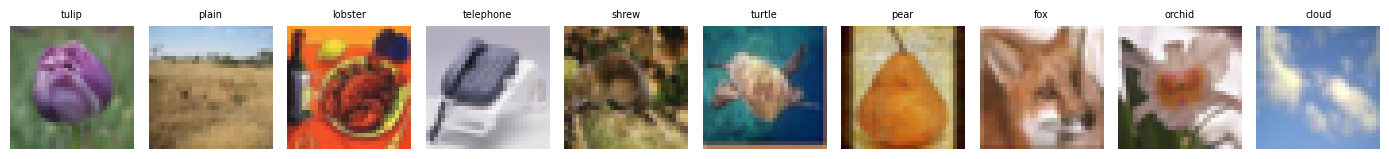

In [3]:
def show_cifar100_samples(loader, n: int = 10, class_names: list = None):
    """Визуализация примеров из CIFAR100"""
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Денормализация для отображения
        img = x[i].permute(1, 2, 0) * torch.tensor(CIFAR100_STD) + torch.tensor(CIFAR100_MEAN)
        img = img.clamp(0, 1).numpy()
        plt.imshow(img)
        if class_names:
            plt.title(class_names[y[i].item()], fontsize=7)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Создаем простой DataLoader для проверки
temp_loader = DataLoader(ds_train_full, batch_size=16, shuffle=True)
batch = next(iter(temp_loader))
x, y = batch
print(f"x.shape: {x.shape}, y.shape: {y.shape}")
print(f"x.dtype: {x.dtype}, y.dtype: {y.dtype}")

show_cifar100_samples(temp_loader, n=10, class_names=class_names)

Разделение train/val/test

In [4]:
def make_loaders_cifar100(
    ds_train_full, ds_test, batch_size: int = 128, 
    val_ratio: float = 0.2, seed: int = RANDOM_STATE
):
    """Создание DataLoader с валидационным разбиением"""
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val
    
    # Фиксированный seed для воспроизводимости
    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )
    
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, 
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, 
                            num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, 
                             num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

Простая CNN архитектура

In [5]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    """Простая CNN для CIFAR100"""
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Блок 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Блок 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

# Проверка архитектуры
cnn = SimpleCNN(num_classes=100).to(DEVICE)
print(f"SimpleCNN params: {count_params(cnn):,}")

# Sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 32, 32).to(DEVICE)
    y0 = cnn(x0)
    print(f"Input: {x0.shape} Output: {y0.shape}")

SimpleCNN params: 643,940
Input: torch.Size([2, 3, 32, 32]) Output: torch.Size([2, 100])


Функции обучения и оценки

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, 
        epochs: int = 10, device=DEVICE, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        
        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                  f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s")
        
        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break
    
    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))
    
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title} | loss")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{title} | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

Эксперименты

C1: Simple CNN без аугментаций

In [7]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 3

results = []

# ========== C1: Simple CNN без аугментаций ==========
print("C1: Simple CNN - no augmentations")

ds_train_c1, ds_test_c1 = load_cifar100(train_transform=base_transform, eval_transform=base_transform)
train_loader_c1, val_loader_c1, test_loader_c1 = make_loaders_cifar100(ds_train_c1, ds_test_c1)

model_c1 = SimpleCNN(num_classes=100).to(DEVICE)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1 = fit(model_c1, train_loader_c1, val_loader_c1, optimizer_c1, criterion, epochs=EPOCHS)

best_val_acc_c1 = max(hist_c1["val_acc"])
test_acc_c1 = evaluate(model_c1, test_loader_c1, criterion, DEVICE)[1]

results.append({
    "experiment_id": "C1", "task": "classification", "dataset": "CIFAR100",
    "seed": RANDOM_STATE, "model_summary": "SimpleCNN(32-64-128)",
    "optimizer": "Adam", "lr": 1e-3, "epochs_trained": EPOCHS,
    "best_val_accuracy": best_val_acc_c1, "test_accuracy": test_acc_c1,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "Base CNN, no augmentations"
})
print(f"C1: best_val_acc={best_val_acc_c1:.4f}, test_acc={test_acc_c1:.4f}")

C1: Simple CNN - no augmentations
Files already downloaded and verified
Files already downloaded and verified
Epoch 01/3 | train loss 4.0284, acc 0.080 | val loss 3.4258, acc 0.180 | 15.8s
Epoch 02/3 | train loss 3.4971, acc 0.152 | val loss 3.0484, acc 0.246 | 15.7s
Epoch 03/3 | train loss 3.2385, acc 0.192 | val loss 2.8295, acc 0.285 | 15.9s
C1: best_val_acc=0.2853, test_acc=0.2863


C2: Simple CNN с аугментациями

In [8]:
# ========== C2: Simple CNN с аугментациями ==========
print("C2: Simple CNN - with augmentations")

ds_train_c2, ds_test_c2 = load_cifar100(train_transform=aug_transform, eval_transform=base_transform)
train_loader_c2, val_loader_c2, test_loader_c2 = make_loaders_cifar100(ds_train_c2, ds_test_c2)

model_c2 = SimpleCNN(num_classes=100).to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion, epochs=EPOCHS)

best_val_acc_c2 = max(hist_c2["val_acc"])
test_acc_c2 = evaluate(model_c2, test_loader_c2, criterion, DEVICE)[1]

results.append({
    "experiment_id": "C2", "task": "classification", "dataset": "CIFAR100",
    "seed": RANDOM_STATE, "model_summary": "SimpleCNN(32-64-128)",
    "optimizer": "Adam", "lr": 1e-3, "epochs_trained": EPOCHS,
    "best_val_accuracy": best_val_acc_c2, "test_accuracy": test_acc_c2,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "Same CNN + augmentations (flip, crop, color jitter)"
})
print(f"C2: best_val_acc={best_val_acc_c2:.4f}, test_acc={test_acc_c2:.4f}")

C2: Simple CNN - with augmentations
Files already downloaded and verified
Files already downloaded and verified
Epoch 01/3 | train loss 4.2219, acc 0.052 | val loss 3.8164, acc 0.108 | 19.5s
Epoch 02/3 | train loss 3.8239, acc 0.099 | val loss 3.5284, acc 0.158 | 23.3s
Epoch 03/3 | train loss 3.6519, acc 0.121 | val loss 3.3042, acc 0.193 | 21.4s
C2: best_val_acc=0.1934, test_acc=0.2100


Files already downloaded and verified


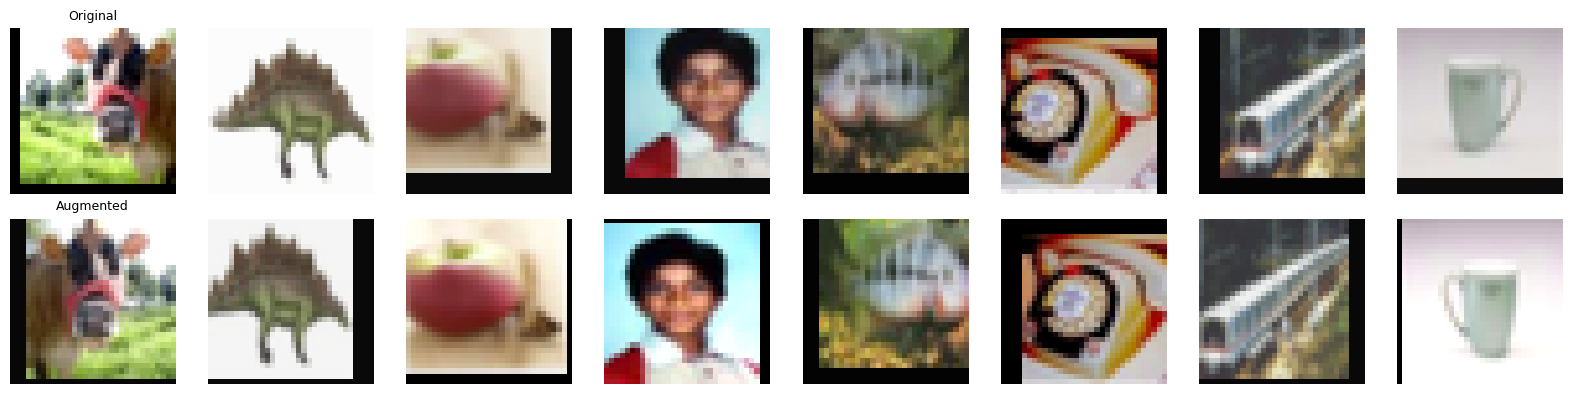

In [9]:
# Визуализация аугментаций
def visualize_augmentations(dataset, n: int = 8):
    """Показать примеры аугментаций"""
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    
    # Оригинальные изображения
    for i in range(n):
        img, _ = dataset[i]
        img_denorm = img.permute(1, 2, 0) * torch.tensor(CIFAR100_STD) + torch.tensor(CIFAR100_MEAN)
        axes[0, i].imshow(img_denorm.clamp(0, 1))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=9)
    
    # Аугментированные изображения
    aug_dataset = torchvision.datasets.CIFAR100(
        root="./data", train=True, download=True, transform=aug_transform
    )
    for i in range(n):
        img, _ = aug_dataset[i]
        img_denorm = img.permute(1, 2, 0) * torch.tensor(CIFAR100_STD) + torch.tensor(CIFAR100_MEAN)
        axes[1, i].imshow(img_denorm.clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Augmented", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150, bbox_inches='tight')
    plt.show()

visualize_augmentations(ds_train_c2)

C3: ResNet18 - head only (frozen backbone)

In [10]:
# ========== C3: ResNet18 - head only (frozen backbone) ==========
print("C3: ResNet18 pretrained - head only")

def build_resnet18_cifar100(num_classes: int = 100, freeze_backbone: bool = True):
    """Создание ResNet18 для CIFAR100"""
    try:
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    except:
        model = resnet18(weights=None)
    
    # Замена последнего слоя под 100 классов
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    
    return model

ds_train_c3, ds_test_c3 = load_cifar100(train_transform=resnet_transform_train, 
                                         eval_transform=resnet_transform_eval)
train_loader_c3, val_loader_c3, test_loader_c3 = make_loaders_cifar100(ds_train_c3, ds_test_c3, batch_size=64)

model_c3 = build_resnet18_cifar100(num_classes=100, freeze_backbone=True).to(DEVICE)
optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3 = fit(model_c3, train_loader_c3, val_loader_c3, optimizer_c3, criterion, epochs=EPOCHS)

best_val_acc_c3 = max(hist_c3["val_acc"])
test_acc_c3 = evaluate(model_c3, test_loader_c3, criterion, DEVICE)[1]

results.append({
    "experiment_id": "C3", "task": "classification", "dataset": "CIFAR100",
    "seed": RANDOM_STATE, "model_summary": "ResNet18-pretrained-head-only",
    "optimizer": "Adam", "lr": 1e-3, "epochs_trained": EPOCHS,
    "best_val_accuracy": best_val_acc_c3, "test_accuracy": test_acc_c3,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "Pretrained ResNet18, frozen backbone, train fc only"
})
print(f"C3: best_val_acc={best_val_acc_c3:.4f}, test_acc={test_acc_c3:.4f}")

C3: ResNet18 pretrained - head only
Files already downloaded and verified
Files already downloaded and verified
Epoch 01/3 | train loss 2.6089, acc 0.389 | val loss 1.8563, acc 0.513 | 91.6s
Epoch 02/3 | train loss 1.7466, acc 0.536 | val loss 1.6626, acc 0.545 | 91.9s
Epoch 03/3 | train loss 1.5906, acc 0.565 | val loss 1.5674, acc 0.566 | 92.0s
C3: best_val_acc=0.5658, test_acc=0.5608


C4: ResNet18 - fine-tune (layer4 + fc)

In [11]:
# ========== C4: ResNet18 - fine-tune (layer4 + fc) ==========
print("C4: ResNet18 pretrained - fine-tune layer4+fc")

model_c4 = build_resnet18_cifar100(num_classes=100, freeze_backbone=True).to(DEVICE)

# Размораживаем layer4 и fc
for param in model_c4.layer4.parameters():
    param.requires_grad = True
for param in model_c4.fc.parameters():
    param.requires_grad = True

# Разные LR для backbone и head
optimizer_c4 = torch.optim.Adam([
    {"params": model_c4.layer4.parameters(), "lr": 1e-4},
    {"params": model_c4.fc.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

hist_c4 = fit(model_c4, train_loader_c3, val_loader_c3, optimizer_c4, criterion, epochs=EPOCHS)

best_val_acc_c4 = max(hist_c4["val_acc"])
test_acc_c4 = evaluate(model_c4, test_loader_c3, criterion, DEVICE)[1]

results.append({
    "experiment_id": "C4", "task": "classification", "dataset": "CIFAR100",
    "seed": RANDOM_STATE, "model_summary": "ResNet18-pretrained-finetune",
    "optimizer": "Adam(2-LR)", "lr": "1e-4/1e-3", "epochs_trained": EPOCHS,
    "best_val_accuracy": best_val_acc_c4, "test_accuracy": test_acc_c4,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "Pretrained ResNet18, fine-tune layer4+fc with different LR"
})
print(f"C4: best_val_acc={best_val_acc_c4:.4f}, test_acc={test_acc_c4:.4f}")

C4: ResNet18 pretrained - fine-tune layer4+fc
Epoch 01/3 | train loss 1.6861, acc 0.552 | val loss 1.1162, acc 0.669 | 109.7s
Epoch 02/3 | train loss 0.9393, acc 0.721 | val loss 1.0009, acc 0.707 | 109.0s
Epoch 03/3 | train loss 0.7273, acc 0.777 | val loss 0.9521, acc 0.722 | 113.1s
C4: best_val_acc=0.7221, test_acc=0.7288



Лучший эксперимент: C4 (val_acc=0.7221)
Сохранена модель: artifacts\best_classifier.pt


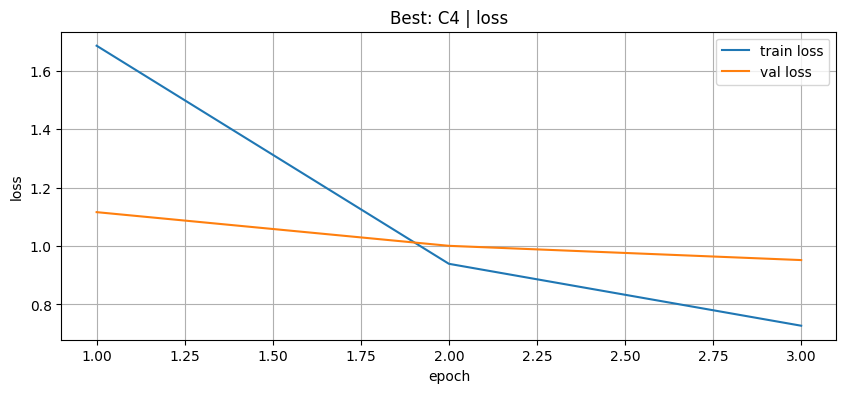

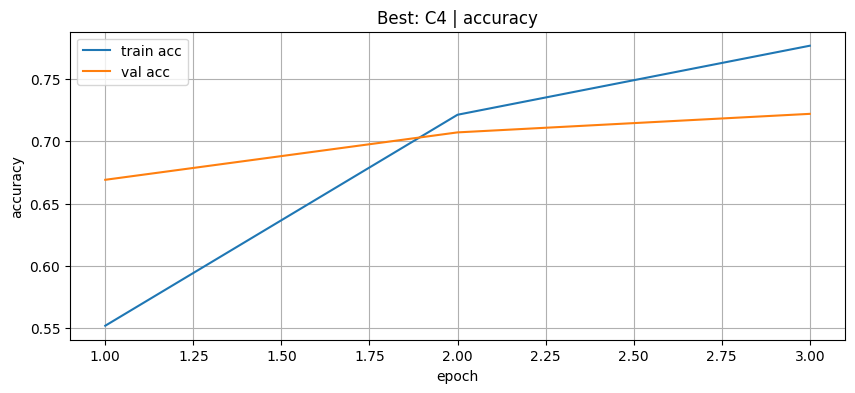

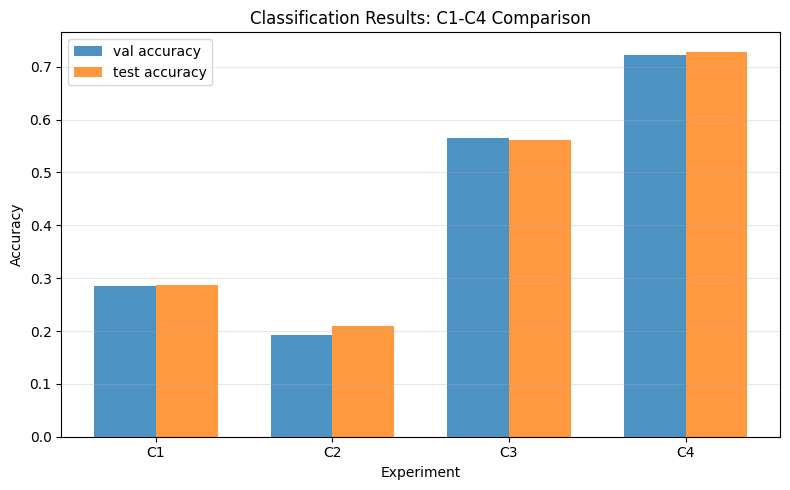

In [12]:
# Выбор лучшей модели по best_val_accuracy
classification_results = [r for r in results if r["task"] == "classification"]
best_exp = max(classification_results, key=lambda x: x["best_val_accuracy"])
print(f"\nЛучший эксперимент: {best_exp['experiment_id']} "
      f"(val_acc={best_exp['best_val_accuracy']:.4f})")

# Определение модели для сохранения
if best_exp["experiment_id"] in ["C1", "C2"]:
    best_model = SimpleCNN(num_classes=100)
    best_model.load_state_dict(model_c1.state_dict() if best_exp["experiment_id"]=="C1" else model_c2.state_dict())
    best_transform = base_transform if best_exp["experiment_id"]=="C1" else aug_transform
else:  # C3 или C4
    best_model = build_resnet18_cifar100(num_classes=100, freeze_backbone=False)
    best_model.load_state_dict(model_c4.state_dict())  # C4 обычно лучше
    best_transform = resnet_transform_eval

# Сохранение модели
torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")
print(f"Сохранена модель: {ARTIFACTS_DIR / 'best_classifier.pt'}")

# Сохранение конфига
config = {
    "dataset": "CIFAR100",
    "architecture": best_exp["model_summary"],
    "num_classes": 100,
    "transforms": {
        "mean": CIFAR100_MEAN if "SimpleCNN" in best_exp["model_summary"] else IMAGENET_MEAN,
        "std": CIFAR100_STD if "SimpleCNN" in best_exp["model_summary"] else IMAGENET_STD,
        "resize": 224 if "ResNet" in best_exp["model_summary"] else 32
    },
    "optimizer": best_exp["optimizer"],
    "lr": best_exp["lr"],
    "epochs": best_exp["epochs_trained"],
    "seed": RANDOM_STATE,
    "best_val_accuracy": best_exp["best_val_accuracy"],
    "test_accuracy": best_exp["test_accuracy"]
}
with open(ARTIFACTS_DIR / "best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=2)

# График кривых обучения для лучшего эксперимента
best_hist = {"C1": hist_c1, "C2": hist_c2, "C3": hist_c3, "C4": hist_c4}[best_exp["experiment_id"]]
plot_history(best_hist, title=f"Best: {best_exp['experiment_id']}")
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches='tight')
plt.close()

# Сравнение C1-C4
exp_ids = [r["experiment_id"] for r in classification_results]
val_accs = [r["best_val_accuracy"] for r in classification_results]
test_accs = [r["test_accuracy"] for r in classification_results]

plt.figure(figsize=(8, 5))
x = np.arange(len(exp_ids))
width = 0.35
plt.bar(x - width/2, val_accs, width, label='val accuracy', alpha=0.8)
plt.bar(x + width/2, test_accs, width, label='test accuracy', alpha=0.8)
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.title("Classification Results: C1-C4 Comparison")
plt.xticks(x, exp_ids)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150, bbox_inches='tight')
plt.show()

Часть B: Сегментация на OxfordIIITPet

Загрузка датасета

In [13]:
# OxfordIIITPet для сегментации
# target_types="segmentation" возвращает trimap: 1=foreground, 2=background, 3=boundary [[38]]

class OxfordIIITPetSeg(Dataset):
    """Dataset для сегментации с бинарной маской (пет/фон)"""
    def __init__(self, root: str, split: str = "trainval", transform=None):
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root, split=split, target_types="segmentation", 
            transform=transform, download=True
        )
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, trimap = self.dataset[idx]  # trimap: PIL Image с значениями 1,2,3
        
        # Конвертируем trimap в бинарную маску: 1=пет (foreground), 2,3=фон
        trimap_np = np.array(trimap)
        binary_mask = (trimap_np == 1).astype(np.uint8)  # Только foreground
        
        return img, binary_mask

# Загрузка
PET_ROOT = "./data"
pet_dataset = OxfordIIITPetSeg(root=PET_ROOT, split="trainval")
print(f"OxfordIIITPet samples: {len(pet_dataset)}")

# Пример данных
img, mask = pet_dataset[0]
print(f"Image size: {img.size}, Mask shape: {mask.shape}")
print(f"Mask unique values: {np.unique(mask)}")  # Должно быть [0, 1]

100%|███████████████████████████████████████████████████████████████████████████████| 792M/792M [00:34<00:00, 23.1MB/s]


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100%|█████████████████████████████████████████████████████████████████████████████| 19.2M/19.2M [00:01<00:00, 12.0MB/s]


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet
OxfordIIITPet samples: 3680
Image size: (394, 500), Mask shape: (500, 394)
Mask unique values: [0 1]


Загрузка предобученной модели сегментации

In [14]:
# Загрузка DeepLabV3 с предобученными весами
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model_seg = deeplabv3_resnet50(weights=weights).to(DEVICE)
model_seg.eval()

# Получение категорий и индекса класса "person" или "pet"
categories = weights.meta.get("categories", [])
print(f"Model categories: {len(categories)}")

# Для OxfordIIITPet мы сегментируем "пет" как foreground
# Используем подход: объединяем все классы животных в один foreground
# Или можно выбрать конкретные классы из COCO: cat(16), dog(18)
PERSON_IDX = categories.index("cat") if "cat" in categories else 15
DOG_IDX = categories.index("dog") if "dog" in categories else 18
print(f"Cat index: {PERSON_IDX}, Dog index: {DOG_IDX}")

# Препроцессинг для модели
preprocess = weights.transforms()
print(f"Preprocess: {preprocess}")

Model categories: 21
Cat index: 8, Dog index: 12
Preprocess: SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Инференс и постобработка

In [15]:
@torch.no_grad()
def predict_segmentation(img_pil: Image.Image, model, device, 
                         mode: str = "V1") -> torch.Tensor:
    """
    Предсказание маски сегментации.
    
    mode: 
      - "V1": базовая постобработка (порог на logits)
      - "V2": альтернативная (более высокий порог + простая очистка)
    """
    x = preprocess(img_pil).unsqueeze(0).to(device)  # [1, 3, H, W] на GPU
    out = model(x)["out"][0]  # [C, H, W] на GPU
    
    if mode == "V1":
        # Базовая: берём классы животных как foreground
        pred_cat = (out[PERSON_IDX] > 0)
        pred_dog = (out[DOG_IDX] > 0)
        pred_foreground = pred_cat | pred_dog
        mask = pred_foreground.to(torch.uint8)
        
    elif mode == "V2":
        # Альтернативная: более высокий порог + простая очистка через numpy
        pred_cat = (out[DOG_IDX] > 0.7)  # Более строгий порог
        pred_dog = (out[PERSON_IDX] > 0.7)
        pred_foreground = pred_cat | pred_dog
        
        # Конвертируем в numpy
        mask_np = pred_foreground.cpu().numpy().astype(np.uint8)
        
        # Простая морфология через numpy (без cv2)
        # Удаляем одиночные пиксели (шум)
        from scipy.ndimage import binary_opening, binary_closing
        mask_np = binary_opening(mask_np, structure=np.ones((3,3))).astype(np.uint8)
        mask_np = binary_closing(mask_np, structure=np.ones((3,3))).astype(np.uint8)
        
        mask = torch.from_numpy(mask_np).to(torch.uint8)
    
    else:
        raise ValueError(f"Unknown mode: {mode}")
    
    # Возвращаем маску на CPU
    return mask.cpu(), out.shape[-2:]  # mask: [H,W] на CPU, size: (H,W)
    
    return mask.cpu(), out.shape[-2:]  # mask: [H,W] на CPU, size: (H,W)
    
def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """IoU для бинарных масок"""

    pred = pred.cpu().bool()
    gt = gt.cpu().bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9)) if union > 0 else 1.0

Оценка и визуализация

In [16]:
def evaluate_segmentation(dataset, model, device, mode: str = "V1", 
                          n_samples: int = 50) -> Dict[str, float]:
    """Оценка качества сегментации"""
    ious = []
    
    for i in range(min(n_samples, len(dataset))):
        img_pil, gt_np = dataset[i]  # gt_np: numpy array [H,W] с 0/1
        
        pred_mask, (h, w) = predict_segmentation(img_pil, model, device, mode=mode)

        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)  # на CPU
        
        iou = iou_binary(pred_mask, gt_mask)
        ious.append(iou)
    
    return {
        "mean_iou": float(np.mean(ious)),
        "median_iou": float(np.median(ious)),
        "std_iou": float(np.std(ious)),
        "n_samples": len(ious)
    }

# Оценка двух режимов
print("\n" + "="*60)
print("Part B: Segmentation evaluation")
print("="*60)

metrics_v1 = evaluate_segmentation(pet_dataset, model_seg, DEVICE, mode="V1", n_samples=50)
metrics_v2 = evaluate_segmentation(pet_dataset, model_seg, DEVICE, mode="V2", n_samples=50)

print(f"V1 (basic):     mean_IoU = {metrics_v1['mean_iou']:.4f}")
print(f"V2 (morphology): mean_IoU = {metrics_v2['mean_iou']:.4f}")

# Добавляем результаты в results
results.append({
    "experiment_id": "V1", "task": "segmentation", "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE, "model_summary": "DeepLabV3-ResNet50-COCO",
    "optimizer": None, "lr": None, "epochs_trained": 0,
    "best_val_accuracy": None, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": metrics_v1["mean_iou"],
    "notes": "Basic postprocessing: threshold on cat/dog classes"
})

results.append({
    "experiment_id": "V2", "task": "segmentation", "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE, "model_summary": "DeepLabV3-ResNet50-COCO",
    "optimizer": None, "lr": None, "epochs_trained": 0,
    "best_val_accuracy": None, "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": metrics_v2["mean_iou"],
    "notes": "Morphological cleanup: close+open with 3x3 kernel"
})


Part B: Segmentation evaluation
V1 (basic):     mean_IoU = 0.2819
V2 (morphology): mean_IoU = 0.3259


Визуализация результатов сегментации


Визуализация V1:


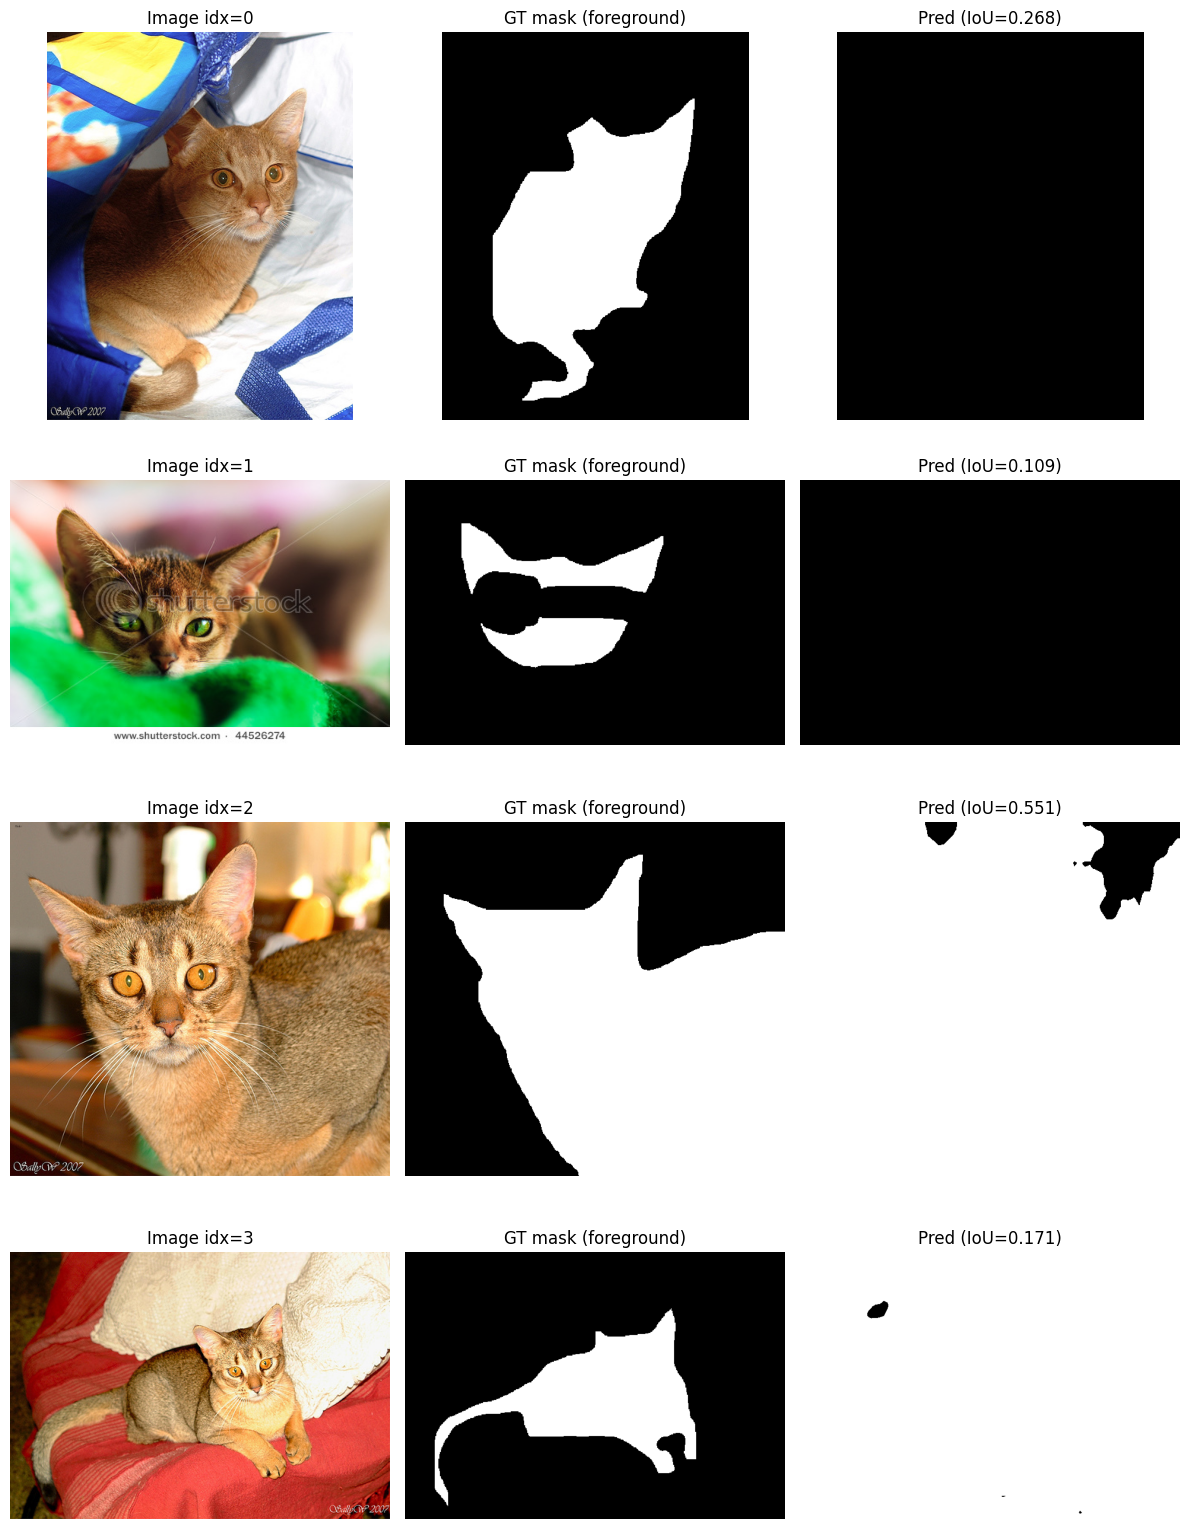


Визуализация V2:


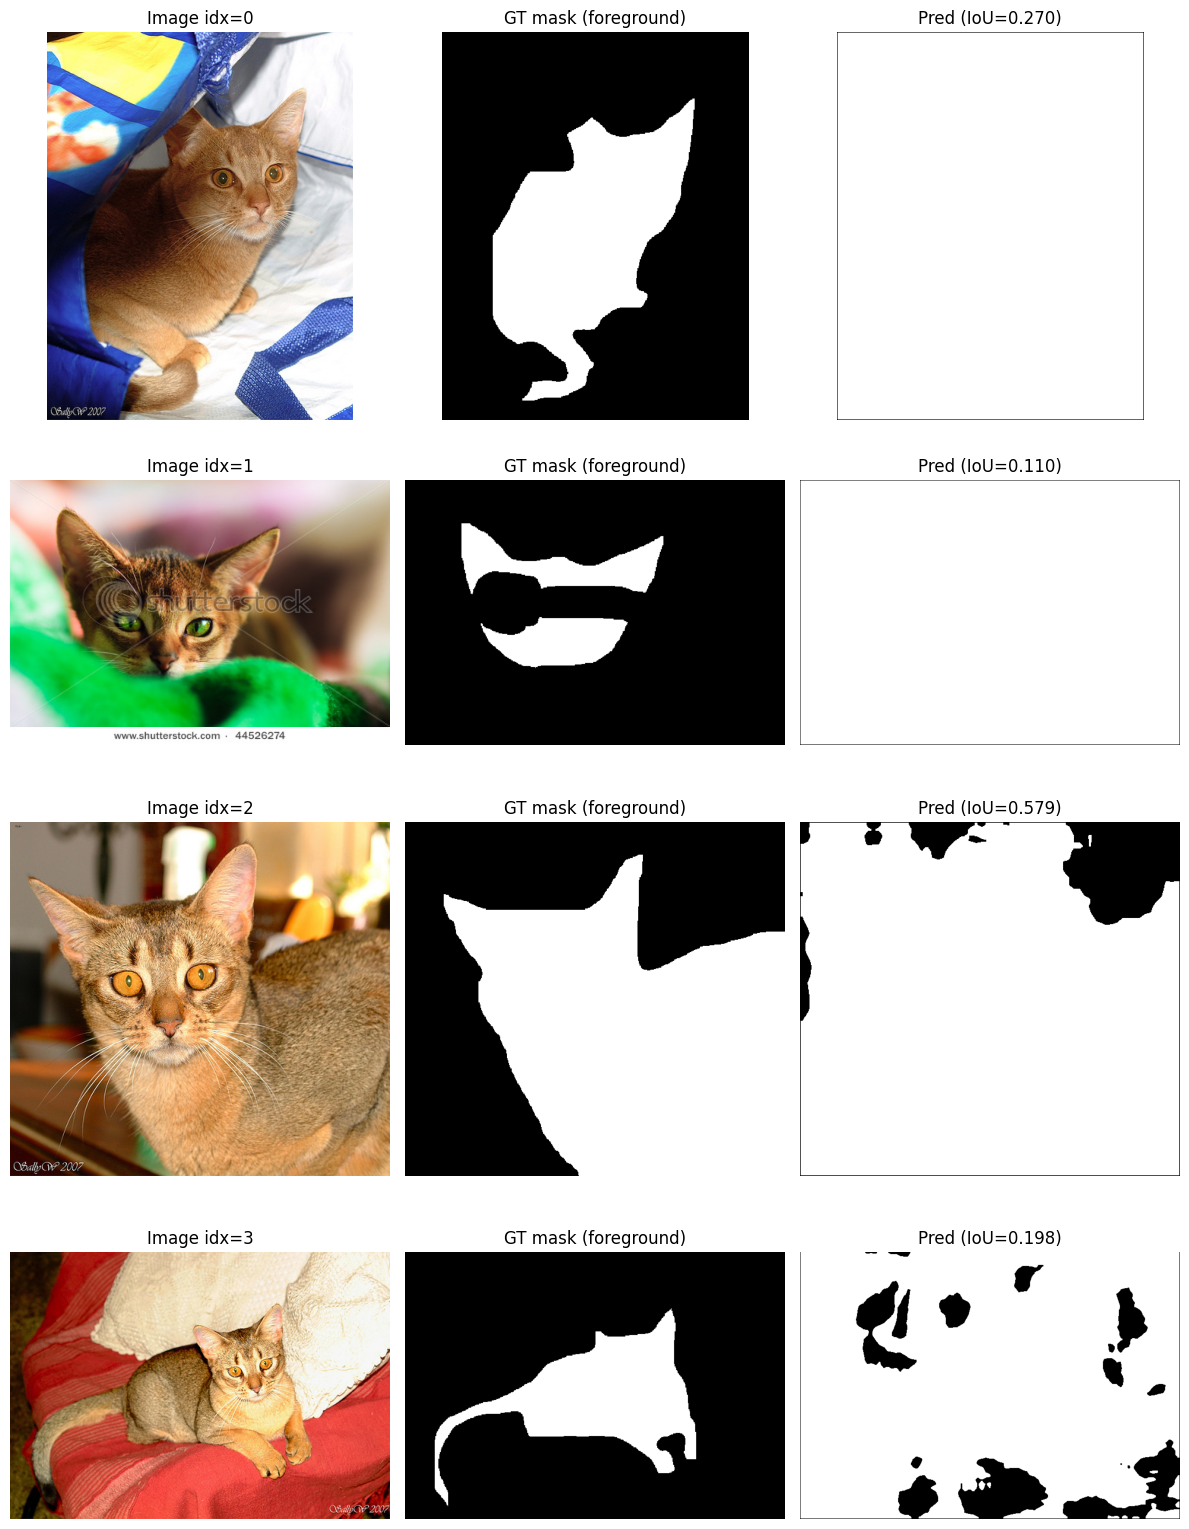

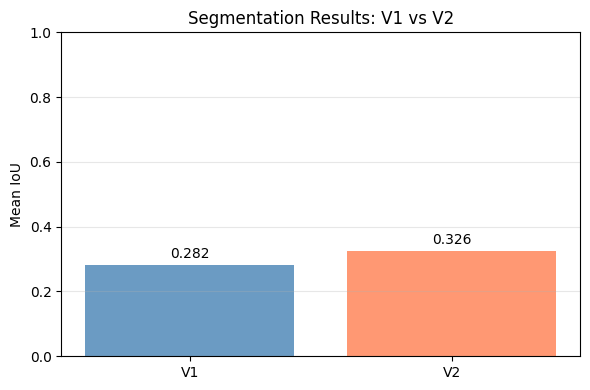

In [17]:
def visualize_segmentation(dataset, model, device, n: int = 4, mode: str = "V1"):
    """Визуализация предсказаний сегментации"""
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    
    for row in range(n):
        img_pil, gt_np = dataset[row]
        pred_mask, (h, w) = predict_segmentation(img_pil, model, device, mode=mode)
        
        # Resize GT
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        
        iou = iou_binary(pred_mask, gt_mask)
        
        # Original image
        axes[row, 0].imshow(img_pil)
        axes[row, 0].set_title(f"Image idx={row}")
        axes[row, 0].axis("off")
        
        # GT mask
        axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
        axes[row, 1].set_title("GT mask (foreground)")
        axes[row, 1].axis("off")
        
        # Prediction
        axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
        axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
        axes[row, 2].axis("off")
    
    plt.tight_layout()
    filename = f"segmentation_examples_{mode}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

print("\nВизуализация V1:")
visualize_segmentation(pet_dataset, model_seg, DEVICE, n=4, mode="V1")

print("\nВизуализация V2:")
visualize_segmentation(pet_dataset, model_seg, DEVICE, n=4, mode="V2")

# График метрик
modes = ["V1", "V2"]
ious = [metrics_v1["mean_iou"], metrics_v2["mean_iou"]]

plt.figure(figsize=(6, 4))
plt.bar(modes, ious, color=["steelblue", "coral"], alpha=0.8)
plt.ylabel("Mean IoU")
plt.title("Segmentation Results: V1 vs V2")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(ious):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Сохранение всех результатов
df_results = pd.DataFrame(results)
df_results.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print(f"\nРезультаты сохранены в: {ARTIFACTS_DIR / 'runs.csv'}")
print(df_results[["experiment_id", "task", "best_val_accuracy", "test_accuracy", "mean_iou"]])


Результаты сохранены в: artifacts\runs.csv
  experiment_id            task  best_val_accuracy  test_accuracy  mean_iou
0            C1  classification             0.2853         0.2863       NaN
1            C2  classification             0.1934         0.2100       NaN
2            C3  classification             0.5658         0.5608       NaN
3            C4  classification             0.7221         0.7288       NaN
4            V1    segmentation                NaN            NaN  0.281876
5            V2    segmentation                NaN            NaN  0.325916
